# Dual Number Automatic Differentiation - A Gentle Introduction

This tutorial demonstrates how to use the `dual_autodiff` package for automatic differentiation using dual numbers.

## Table of Contents
1. Understanding Dual Numbers
2. Getting Started
3. Basic Operations
4. Computing Derivatives
5. Real-World Application
6. Comparing Methods
7. Performance Analysis


## Understanding Dual Numbers
Think of dual numbers as an extension of real numbers, similar to how complex numbers work. While complex numbers have a real part and an imaginary part with i² = -1, dual numbers have:
    

A real part (a),
    A dual part (b),
    A dual unit (ε) where ε² = 0

For example: 2 + 3ε is a dual number where:
    2 is the real part,
    3 is the dual part,
    ε is the dual unit
    

The magic happens when we use these numbers for differentiation - the dual part automatically gives us the derivative!

## Getting Started
First, let's import some useful notebooks.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dual_autodiff import Dual

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


## Basic Operations

Let's explore how dual numbers work with basic arithmetic. Think of these operations as building blocks for more complex calculations.

In [2]:
x=Dual(1,2) #1+2ε
y=Dual(3,4) #3+4ε

#Let's see what happens when we perform basic operations
print(f"Starting Values:")
print(f"x={x.real}+{x.dual}ε")
print(f"y={y.real}+{y.dual}ε")


print(f"Addition: x+y={(x+y).real}+{(x+y).dual}ε")
print(f"Subtraction: x-y={(y-x).real}+{(y-x).dual}ε")
print(f"Multiplication: x*y={(x*y).real}+{(x*y).dual}ε")
print(f"Division: x/y={(x/y).real:.2g}+{(x/y).dual:.2g}ε")

Starting Values:
x=1.0+2.0ε
y=3.0+4.0ε
Addition: x+y=4.0+6.0ε
Subtraction: x-y=2.0+2.0ε
Multiplication: x*y=3.0+10.0ε
Division: x/y=0.33+0.22ε


## Computing Derivatives

Now for the exciting part - computing derivatives! We'll look at some common functions and compare our results with known analytical solutions.

You can use dual number operations on numbers to calculate the value of f(x) while also calculating f'(x) at the same time. 

We will start with the function 
$$
f(x)=3x+2
$$
and we will calculate f(4) and f'(4).

The first thing we do is convert our 4 into a dual number, using 1 for the dual component, since we are plugging it in for the value of x, which has a derivative of 1.
$$ 4+1\epsilon$$

Next, we want to multiply that by the constant 3, using 0 for the dual component since it is just a constant (and the derivative of a constant is 0)

$$
(4+1\epsilon) * (3 + 0\epsilon) =
12 + 0\epsilon + 3\epsilon + 0\epsilon^2 =
12 + 3\epsilon
$$

Lastly, we need to add the constant 2, using 0 again for the dual component since it's just a constant.

$$
(12 + 3\epsilon) + (2 + 0\epsilon) =
14 + 3\epsilon
$$

In our result, the real number component (14) is the value of f(4) and the dual component (3) is the derivative f'(4), which is correct if you work it out!

We've created a helper function that shows both the original function and its derivative:

In [3]:
def plot_function_and_derivative(f, f_prime, x_range, title):
    """
    Plots a function and its derivative using both dual numbers and analytical methods.
    
    Parameters:
        f: The function to differentiate (should handle both Dual and float inputs)
        f_prime: The known analytical derivative (takes float input)
        x_range: Tuple of (min_x, max_x) for plotting range
        title: Title for the plot
        
    Example:
        >>> # Plot sin(x) and its derivative
        >>> plot_function_and_derivative(
        ...     lambda x: x.sin() if isinstance(x, Dual) else np.sin(x),
        ...     lambda x: np.cos(x),
        ...     [-2*np.pi, 2*np.pi],
        ...     'sin(x)'
        ... )
    """
    # Create array of x values for plotting
    x = np.linspace(x_range[0], x_range[1], 100)
    
    # Calculate function values
    y = [f(xi) for xi in x]
    
    # Compute derivatives using both methods
    derivatives_dual = [f(Dual(xi, 1.0)).dual for xi in x]  # Dual number method
    derivatives_analytical = [f_prime(xi) for xi in x]       # Analytical method
    
    # Create subplot figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Left subplot: Original function
    ax1.plot(x, y, 'b-', label='f(x)')
    ax1.set_title(f'{title} - Function')
    ax1.set_xlabel('x')
    ax1.set_ylabel('f(x)')
    ax1.grid(True)
    ax1.legend()
    
    # Right subplot: Derivatives
    ax2.plot(x, derivatives_dual, 'b-', label='Dual Number')
    ax2.plot(x, derivatives_analytical, 'r--', label='Analytical')
    ax2.set_title(f'{title} - Derivative')
    ax2.set_xlabel('x')
    ax2.set_ylabel("f'(x)")
    ax2.grid(True)
    ax2.legend()
    
    # Adjust layout and display
    plt.tight_layout()
    plt.show()


### Sine Function

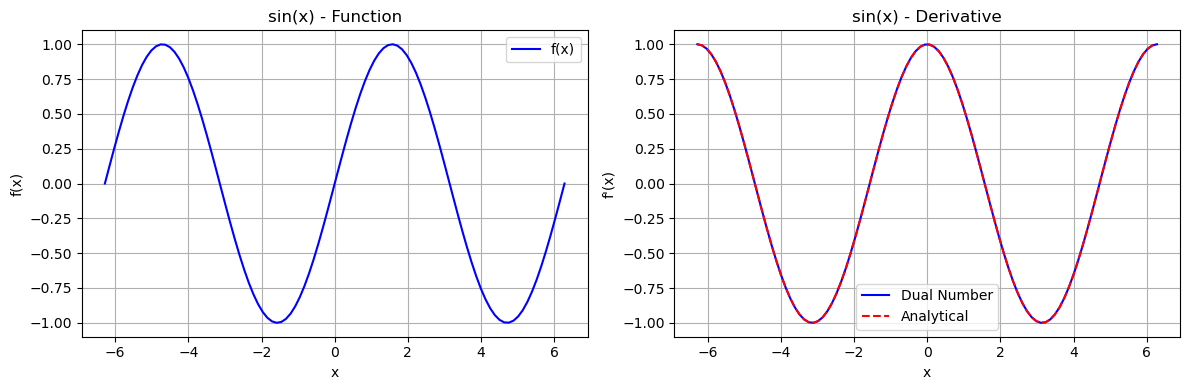

In [4]:
plot_function_and_derivative(
    lambda x: x.sin() if isinstance(x, Dual) else np.sin(x),
    lambda x: np.cos(x),
    [-2*np.pi, 2*np.pi],
    'sin(x)'
)

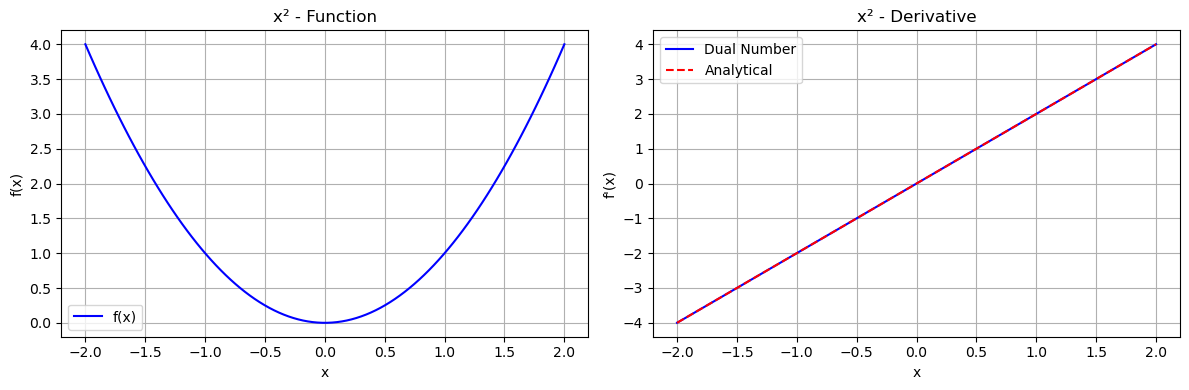

In [5]:
# Example 2: Plotting x²
plot_function_and_derivative(
    lambda x: x * x,
    lambda x: 2*x,
    [-2, 2],
    'x²'
)

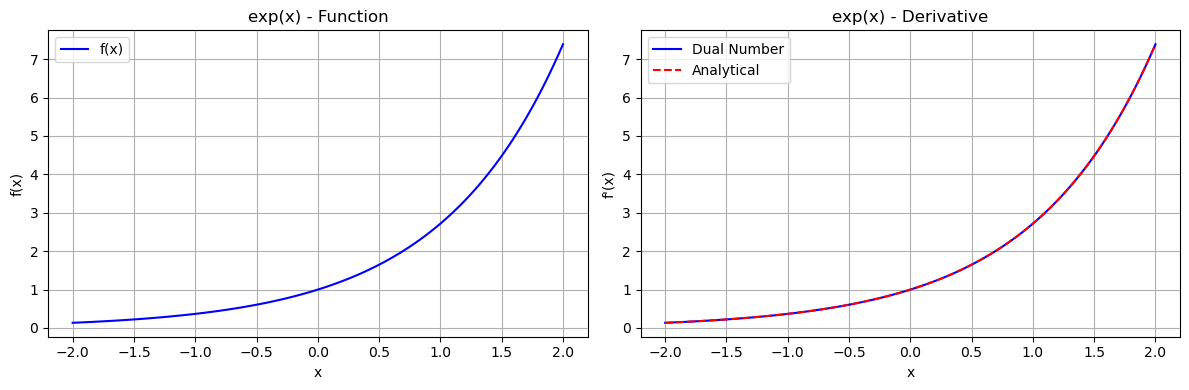

In [6]:
# Example 3: Plotting exp(x)
plot_function_and_derivative(
    lambda x: x.exp() if isinstance(x, Dual) else np.exp(x),
    lambda x: np.exp(x),
    [-2, 2],
    'exp(x)'
)

In [7]:
# Example 4: More complex function: x²sin(x)
def complex_function(x):
    if isinstance(x, Dual):
        return x * x * x.sin()
    return x**2 * np.sin(x)

def complex_derivative(x):
    return 2*x*np.sin(x) + x**2*np.cos(x)

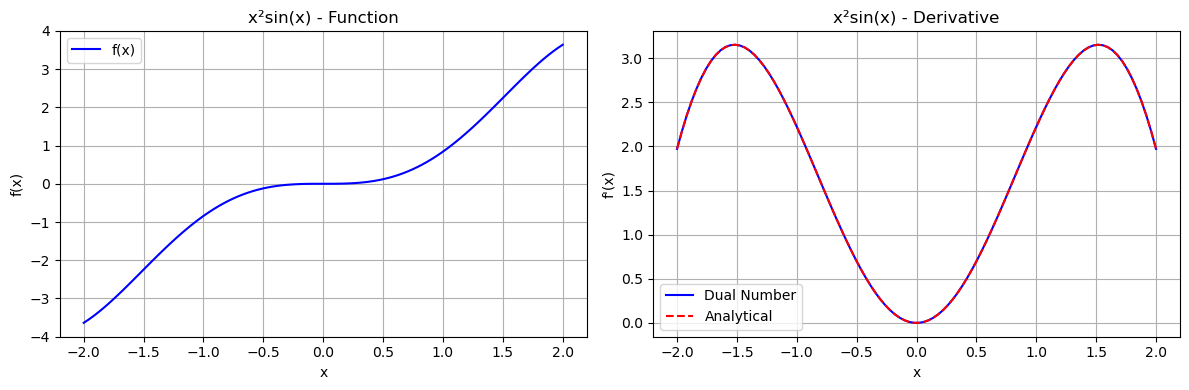

In [8]:
plot_function_and_derivative(
    complex_function,
    complex_derivative,
    [-2, 2],
    'x²sin(x)'
)

## Real-World Application: Portfolio Optimization

Problem Description

When managing an investment portfolio with two assets, investors need to find the optimal balance between them to minimize risk. Let's demonstrate how dual numbers can help us find this optimal allocation.

The Mathematical Model:

The portfolio risk formula is given by:

risk = √(w²σ₁² + (1-w)²σ₂² + 2w(1-w)σ₁σ₂ρ)

where:
- w is the weight of the first asset (0 to 1)
- σ₁ is the volatility of asset 1
- σ₂ is the volatility of asset 2
- ρ is the correlation between assets

Let's implement this with real numbers:

In [9]:
def portfolio_risk(w,volatility1,volatility2,correlation):
    """
    Calculate the risk of a portfolio with two assets.
    
    Parameters:
        w: Array of weights for each asset
        volatility1: Volatility of asset 1
        volatility2: Volatility of asset 2
        correlation: Correlation between assets
        
    Returns:
        The portfolio risk
    """
    # Calculate the portfolio volatility
    if isinstance(w, Dual):
        return (w * w * volatility1**2 + 
                (1-w) * (1-w) * volatility2**2 + 
                2 * w * (1-w) * volatility1 * volatility2 * correlation).sqrt()
    # Handle regular number inputs
    return np.sqrt(w**2 * volatility1**2 + 
                  (1-w)**2 * volatility2**2 + 
                  2 * w * (1-w) * volatility1 * volatility2 * correlation)


In [10]:
# Example portfolio parameters
vol1 = 0.20  
vol2 = 0.30  
corr = 0.50  

In [11]:
weights = np.linspace(0, 1, 100)  # 100 points from 0% to 100%
risks = [portfolio_risk(w, vol1, vol2, corr) for w in weights]

In [12]:
risk_derivatives = [portfolio_risk(Dual(w, 1.0), vol1, vol2, corr).dual 
                   for w in weights]

TypeError: unsupported operand type(s) for -: 'int' and 'Dual'